<div style="text-align:center; padding:18px 0 6px 0"></div>

<div style="text-align:center; color:#8b949e; font-size:12px; padding-bottom:8px">© 2026 QPerfect &middot; Released under the MIT License &middot; <a href="https://qperfect.io">qperfect.io</a></div>

---

# QAOA on MIMIQ — solving a small TSP end-to-end

We've built every piece: a TSP/VRP problem, a Lucas-2014 QUBO encoder, a
QUBO→Ising→`mc.Hamiltonian` reduction, a matplotlib theme, and a
`mimiq_cache` context manager. Time to wire them together.

This notebook takes the four-Strasbourg-market TSP, encodes it as a
**16-qubit** QUBO, builds the QAOA ansatz at depth `p = 4`, and runs the
hybrid loop on MIMIQ. The whole optimisation is wrapped in `mimiq_cache`
so the first run hits the cloud (~10–20 minutes depending on queue) but
every subsequent run replays from disk in seconds — perfect for live
demos.

Two crucial details for the QAOA to actually converge:

1. **Coefficient normalisation.** Lucas-2014 puts penalty terms of order
   `4 · max(d) ≈ 2400` into `Q`. Without normalisation, `RZ(2γ · J_ij)`
   at `γ = 0.5` would rotate by ~1200 radians — the cost layer becomes
   pure noise. We rescale `(h, J)` so `max|coupling| = 1` before QAOA.
2. **Adiabatic-style warm start.** Linear ramp from
   `(β = β_max, γ = 0)` at the first layer to `(β = 0, γ = γ_max)` at
   the last — the discrete analogue of an adiabatic schedule
   `H(s) = (1−s) H_M + s H_C`.

> **Heads-up.** Running this notebook from scratch needs MIMIQ credentials
> (`MIMIQUSER`/`MIMIQPASS` env vars or a one-time `conn.connect()` browser
> hop). After the first successful execution the `.nb_cache/mimiq/`
> directory holds every cloud round-trip, and you can replay offline.


In [1]:
import time
from functools import partial

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

import mimiqcircuits as mc
from strasbourg_markets_demo import strasbourg as s, theme
from strasbourg_markets_demo.cache import mimiq_cache
from strasbourg_markets_demo.qubo import bitstring_to_array, cvar_from_histogram
from strasbourg_markets_demo.tsp import (
    TSPInstance, brute_force as tsp_bf,
    to_qubo as tsp_to_qubo,
    tour_from_bitstring, tour_from_histogram,
)

theme.apply()
RNG_SEED = 2024


## 1. Pick the instance: 4 Strasbourg markets

Four markets, the smallest TSP that has more than one distinct closed
tour ((4-1)!/2 = **3 tours**). Lucas-2014 one-hot ⇒ **16 qubits**.


In [2]:
markets4 = s.tsp_five()[:4]
inst = TSPInstance.from_coords(
    coords=s.coords_array(markets4),
    names=[m.name for m in markets4],
    metric="haversine",
)
print(f"cities: {[m.name for m in markets4]}")
print(f"distance matrix (m):\n{inst.distances.round(1)}")

opt_tour, opt_len = tsp_bf(inst)
print(f"\nclassical optimum: tour={opt_tour.tolist()}  length={opt_len:.1f} m")


cities: ['Place Kléber', 'Place Broglie', 'Cathédrale Notre-Dame (marché)', 'Place du Château']
distance matrix (m):
[[  0.  372.  365.9 456.6]
 [372.    0.  381.6 413.5]
 [365.9 381.6   0.   94. ]
 [456.6 413.5  94.    0. ]]

classical optimum: tour=[0, 1, 3, 2]  length=1245.4 m


## 2. Encode as a Hamiltonian (and normalise it)

`tsp_to_qubo` builds the Lucas-2014 QUBO; `QUBO.to_ising()` returns the
`(h, J, c)` decomposition. We then divide by the maximum-magnitude
coupling so the QAOA angles `(γ, β)` live on a sensible scale.


In [3]:
qubo = tsp_to_qubo(inst)
h, J, c_offset = qubo.to_ising()

# Normalise coefficients to O(1). Without this, the cost-layer rotations
# wrap many times at any reasonable γ and the optimisation never settles.
scale = float(max(np.abs(h).max(), np.abs(J).max()))
h_n = h / scale
J_n = J / scale
print(f"qubits           = {qubo.n_qubits}")
print(f"penalty (Lucas)  = {(4.0 * inst.distances.max()):.1f}")
print(f"max |coupling|   = {scale:.1f}   (rescaled to 1.0 for QAOA angles)")
print(f"Ising constant   = {c_offset:.1f}  (kept for absolute-energy reporting)")

# Build the MIMIQ Hamiltonian on the normalised coefficients.
H_C = mc.Hamiltonian()
n = qubo.n_qubits
for i in range(n):
    if abs(h_n[i]) > 1e-12:
        H_C.push(float(h_n[i]), mc.PauliString("Z"), i)
for i in range(n):
    for j in range(i + 1, n):
        if abs(J_n[i, j]) > 1e-12:
            H_C.push(float(J_n[i, j]), mc.PauliString("ZZ"), i, j)
print(f"# Pauli terms    = {len(H_C)}  (Z and ZZ, normalised)")


qubits           = 16
penalty (Lucas)  = 1826.5
max |coupling|   = 4250.2   (rescaled to 1.0 for QAOA angles)
Ising constant   = 33390.7  (kept for absolute-energy reporting)
# Pauli terms    = 112  (Z and ZZ, normalised)


## 3. Build the QAOA ansatz

The standard ansatz at depth $p$:

$$|\psi(\boldsymbol\gamma, \boldsymbol\beta)\rangle =
  \prod_{k=1}^{p} \Bigl[\, e^{-i \beta_k H_M}\, e^{-i \gamma_k H_C}\, \Bigr]
  \, H^{\otimes n}\, |0\rangle^{\otimes n}$$

with `H_M = Σ_i X_i` (single-qubit X, the standard *X-mixer*).

Below, the cost unitary is implemented manually — one `RZ(2γh_i)` per
linear term and one `RZZ(2γJ_ij)` per coupling — so the gate structure is
visible. (Equivalent to `circuit.push_suzukitrotter(H_C, ..., t=γ, steps=1)`,
which we use in `notes/03-qaoa-on-mimiq-canonical-circuit.md`.)


In [4]:
def build_qaoa(h, J, gammas, betas) -> mc.Circuit:
    """QAOA ansatz: H-wall + p layers of (cost RZ/RZZ + mixer RX)."""
    n = len(h)
    c = mc.Circuit()
    for q in range(n):
        c.push(mc.GateH(), q)
    for gamma, beta in zip(gammas, betas):
        # Cost unitary  exp(-i γ H_C)
        for i in range(n):
            if abs(h[i]) > 1e-12:
                c.push(mc.GateRZ(2.0 * gamma * h[i]), i)
        for i in range(n):
            for j in range(i + 1, n):
                if abs(J[i, j]) > 1e-12:
                    c.push(mc.GateRZZ(2.0 * gamma * J[i, j]), i, j)
        # Mixer unitary  exp(-i β Σ X_i)
        for i in range(n):
            c.push(mc.GateRX(2.0 * beta), i)
    return c


def linear_ramp(p: int, gamma_max: float = np.pi, beta_max: float = np.pi / 2):
    """Adiabatic-style ramp: (β=β_max, γ=0) at first layer, (β=0, γ=γ_max) at last."""
    if p == 1:
        return [0.5 * gamma_max], [0.5 * beta_max]
    s = np.linspace(0.0, 1.0, p)
    return list(s * gamma_max), list((1.0 - s) * beta_max)


# Sanity-check at p=4
P_LAYERS = 4
gammas0, betas0 = linear_ramp(P_LAYERS)
print(f"warm start (p={P_LAYERS}):")
print(f"  gammas (cost weight) = {[round(g, 3) for g in gammas0]}  -- 0 → π")
print(f"  betas  (mixer weight) = {[round(b, 3) for b in betas0]}  -- π/2 → 0")

c_demo = build_qaoa(h_n, J_n, gammas0, betas0)
print(f"\np={P_LAYERS} circuit: {len(c_demo)} instructions, depth {c_demo.depth()}")


warm start (p=4):
  gammas (cost weight) = [np.float64(0.0), np.float64(1.047), np.float64(2.094), np.float64(3.142)]  -- 0 → π
  betas  (mixer weight) = [np.float64(1.571), np.float64(1.047), np.float64(0.524), np.float64(0.0)]  -- π/2 → 0

p=4 circuit: 528 instructions, depth 84


## 4. Connect to MIMIQ

A single connection is reused for the whole optimisation. The
`mimiq_cache` context manager wraps it so each `submit + get_result` pair
falls through to disk on subsequent runs.


In [5]:
conn = mc.MimiqConnection(mc.QPERFECT_CLOUD)
try:
    conn.connect()                 # browser auth on first run; tokens cache
    print(f"connected to {mc.QPERFECT_CLOUD}")
except Exception as exc:
    print(f"could not connect: {exc}")
    print("the rest of the notebook expects a working MimiqConnection.")


[INFO] Listening on: 127.0.0.1:1444, thread id: 140466047477568
[INFO] Please login in your browser at http://localhost:1444
[INFO] Authentication successful.
connected to https://mimiq.qperfect.io


## 5. The QAOA objective — CVaR over the bottom α-fraction

Plain mean energy `⟨H_C⟩` is a noisy objective when most samples are
infeasible (penalty terms dominate). **CVaR-QAOA** (Barkoutsos et al.,
Quantum 2020) fixes this by averaging only over the lowest-α fraction of
sampled energies — concentrating the gradient signal on the part of the
distribution we care about (low-energy candidates, including feasible
tours). `α = 0.2` is the standard default.

`qubo.evaluate` is called on the ORIGINAL un-normalised QUBO so the
energies stay in meaningful units (metres). The QAOA *circuit* uses the
normalised `(h_n, J_n)`, but the *objective* does not.


In [6]:
N_QUBITS = qubo.n_qubits

def qaoa_objective(params, *, conn, qubo, h_n, J_n, p,
                   nsamples=512, bonddim=128, alpha=0.2):
    """CVaR mean of the bottom α-fraction of energies (true QUBO units)."""
    gammas = list(params[:p])
    betas  = list(params[p:])
    circuit = build_qaoa(h_n, J_n, gammas, betas)
    job = conn.submit(circuit, algorithm="mps", bonddim=bonddim,
                      nsamples=nsamples, seed=RNG_SEED,
                      label=f"qaoa-tsp4-p{p}")
    res = conn.get_result(job)
    return cvar_from_histogram(qubo, res.histogram(), alpha=alpha)


## 6. Run COBYLA — wrapped in `mimiq_cache`

Adiabatic-style warm start (`linear_ramp` from §3): cost weight `γ` ramps
0 → π over `p = 4` layers, mixer weight `β` ramps π/2 → 0. COBYLA explores
~30 evaluations from there.

Inside the `with mimiq_cache(...)` block, every `conn.submit / conn.get_result`
pair is hashed by (circuit, kwargs) and persisted to disk on first run;
re-running this cell is instant after that.


In [8]:
x0 = np.array(gammas0 + betas0)

history: list[float] = []
obj = partial(qaoa_objective, conn=conn, qubo=qubo,
              h_n=h_n, J_n=J_n, p=P_LAYERS, nsamples=512, alpha=0.2)

def tracked(params):
    val = obj(params)
    history.append(val)
    return val

t0 = time.perf_counter()
with mimiq_cache(conn, key="qaoa-tsp4-cobyla"):
    res_opt = minimize(tracked, x0, method="COBYLA",
                       options={"rhobeg": 0.4, "maxiter": 40, "disp": False})
elapsed = time.perf_counter() - t0
print(f"\nCOBYLA finished in {elapsed:.1f} s with {len(history)} evaluations.")
print(f"final CVaR ⟨H_C⟩ (α=0.2) = {res_opt.fun:.2f} m")
print(f"optimal angles: {res_opt.x.round(3)}")


[mimiq_cache] hit  'qaoa-tsp4-cobyla__0b1463dfbe2231f3'  (4.2 kB, QCSResults)
[mimiq_cache] hit  'qaoa-tsp4-cobyla__f9d611a3b4a25254'  (4.2 kB, QCSResults)
[mimiq_cache] hit  'qaoa-tsp4-cobyla__4bf8152af0e0c8db'  (4.2 kB, QCSResults)
[mimiq_cache] hit  'qaoa-tsp4-cobyla__13df1197a7f27f1b'  (4.2 kB, QCSResults)
[mimiq_cache] hit  'qaoa-tsp4-cobyla__08ee0ea985ec78f6'  (4.2 kB, QCSResults)
[mimiq_cache] hit  'qaoa-tsp4-cobyla__92f7afec12f9a948'  (4.2 kB, QCSResults)
[mimiq_cache] hit  'qaoa-tsp4-cobyla__6199466f9f29b1b3'  (4.2 kB, QCSResults)
[mimiq_cache] hit  'qaoa-tsp4-cobyla__9cd4de69cad77c33'  (4.2 kB, QCSResults)
[mimiq_cache] hit  'qaoa-tsp4-cobyla__813eb9044616ff22'  (4.2 kB, QCSResults)
[mimiq_cache] hit  'qaoa-tsp4-cobyla__b767d41c2f676108'  (4.2 kB, QCSResults)
[mimiq_cache] hit  'qaoa-tsp4-cobyla__1eabc435968586f5'  (4.2 kB, QCSResults)
[mimiq_cache] hit  'qaoa-tsp4-cobyla__755c80084dd5052a'  (4.2 kB, QCSResults)
[mimiq_cache] hit  'qaoa-tsp4-cobyla__3df924019ea98651'  (4.2 kB

## 7. Convergence + final sampling

A short final sampling run with more shots gives the histogram we'll
decode into tours.


In [9]:
opt_gammas = list(res_opt.x[:P_LAYERS])
opt_betas  = list(res_opt.x[P_LAYERS:])

final_circuit = build_qaoa(h_n, J_n, opt_gammas, opt_betas)
with mimiq_cache(conn, key="qaoa-tsp4-final"):
    final_job = conn.submit(final_circuit, algorithm="mps", bonddim=128,
                            nsamples=4096, seed=RNG_SEED, label="qaoa-tsp4-final")
    final_res = conn.get_result(final_job)
final_hist = final_res.histogram()
print(f"final sampling: {sum(final_hist.values())} shots, "
      f"{len(final_hist)} unique bitstrings")


[mimiq_cache] miss 'qaoa-tsp4-final__4b167ab3540c8bc7', submitting to MIMIQ...
[mimiq_cache] saved 'qaoa-tsp4-final__4b167ab3540c8bc7'  (32.2 kB)
final sampling: 4096 shots, 2627 unique bitstrings


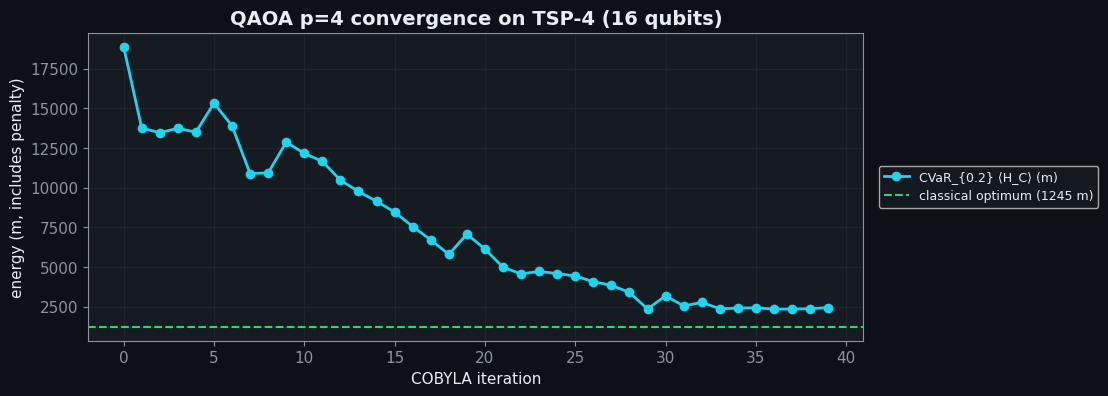

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history, "o-", color=theme.PALETTE["cyan"], lw=2, markersize=6,
        label=r"CVaR_{0.2} ⟨H_C⟩ (m)")
ax.axhline(opt_len, color=theme.PALETTE["green"], ls="--", lw=1.5,
           label=f"classical optimum ({opt_len:.0f} m)")
ax.set_xlabel("COBYLA iteration")
ax.set_ylabel("energy (m, includes penalty)")
ax.set_title(f"QAOA p={P_LAYERS} convergence on TSP-{inst.n} ({N_QUBITS} qubits)")
s.place_legend_outside(ax)
plt.show()


## 8. Decode the top measurement outcomes

The `tour_from_bitstring` helper rejects any bitstring that violates the
Lucas-2014 row/column constraints. We rank the **feasible** outcomes by
empirical probability.


In [11]:
nshots = sum(final_hist.values())
print(f"{'rank':>4}  {'count':>6}  {'prob':>6}  "
      f"{'energy':>9}  {'feas':>5}  tour")
print("-" * 70)
for rank, (bs, count) in enumerate(sorted(final_hist.items(),
                                          key=lambda kv: -kv[1])[:15]):
    decoded = tour_from_bitstring(qubo, bs, n_cities=inst.n)
    e = qubo.evaluate(bs)
    if decoded is not None:
        tour_str = " -> ".join(inst.names[i].split()[0] for i in decoded.tolist())
        feas = "yes"
    else:
        tour_str, feas = "(infeasible)", "no"
    print(f"{rank:>4}  {count:>6}  {count/nshots:>6.3f}  "
          f"{e:>9.1f}  {feas:>5}  {tour_str}")

# Top feasible across the WHOLE histogram (not just top 15).
top_feasible = tour_from_histogram(qubo, final_hist, n_cities=inst.n)
print()
if top_feasible is not None:
    decoded, count, energy = top_feasible
    length = inst.tour_length(decoded)
    print(f"Top-feasible QAOA tour: {decoded.tolist()}  length={length:.1f} m")
    print(f"Classical optimum:      {opt_tour.tolist()}  length={opt_len:.1f} m")
    print(f"Approximation ratio:    {length / opt_len:.4f}  (1.000 = optimal)")


rank   count    prob     energy   feas  tour
----------------------------------------------------------------------
   0      36   0.009     1617.6    yes  Place -> Cathédrale -> Place -> Place
   1      36   0.009     1245.4    yes  Place -> Place -> Place -> Cathédrale
   2      35   0.009     1245.4    yes  Place -> Place -> Place -> Cathédrale
   3      34   0.008     1304.2    yes  Place -> Place -> Cathédrale -> Place
   4      33   0.008     1304.2    yes  Place -> Place -> Cathédrale -> Place
   5      32   0.008     1245.4    yes  Place -> Place -> Place -> Cathédrale
   6      32   0.008     1304.2    yes  Place -> Place -> Cathédrale -> Place
   7      31   0.008     1245.4    yes  Place -> Place -> Place -> Cathédrale
   8      28   0.007     1245.4    yes  Place -> Place -> Place -> Cathédrale
   9      27   0.007     1245.4    yes  Place -> Place -> Place -> Cathédrale
  10      27   0.007     1304.2    yes  Place -> Place -> Cathédrale -> Place
  11      26   0.006     1

## 9. Plot the QAOA tour on the Strasbourg map

Side-by-side: the classical optimum (yellow, dashed) and QAOA's top
feasible outcome (cyan).


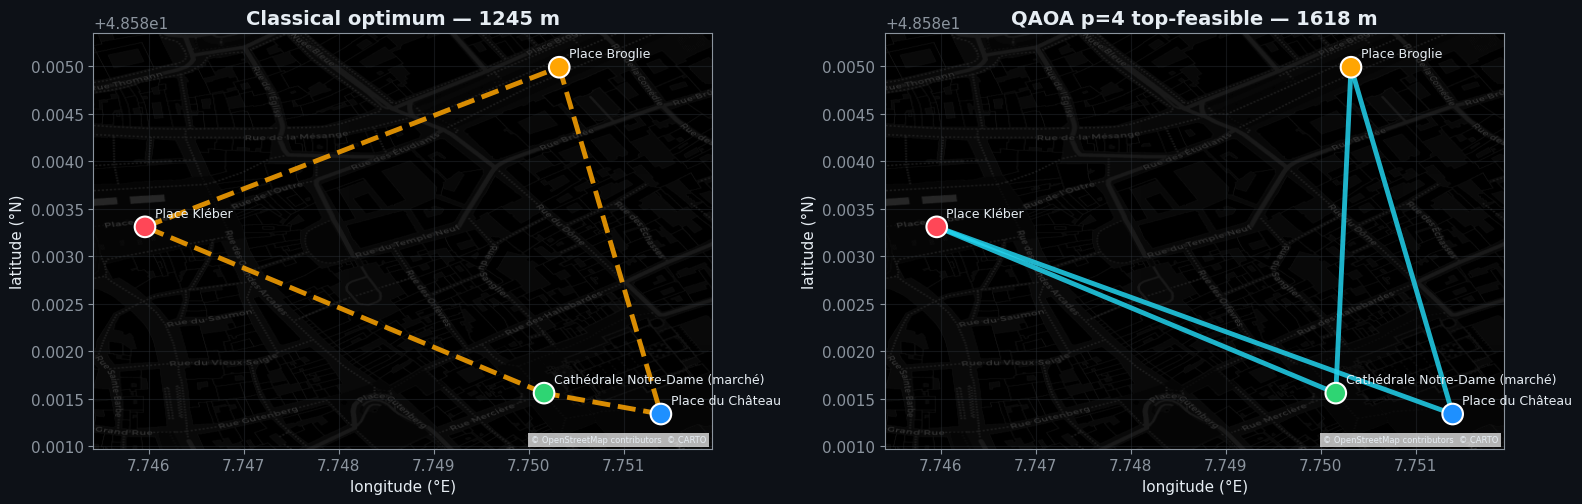

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Classical optimum
opt_places = [markets4[i] for i in opt_tour.tolist()]
opt_edges = list(zip(opt_places, opt_places[1:] + [opt_places[0]]))
s.plot(places=markets4, edges=opt_edges, basemap=True, label="name", ax=axes[0],
       edge_color=theme.PALETTE["yellow"], edge_width=3.5, edge_style="--",
       title=f"Classical optimum — {opt_len:.0f} m")

# QAOA top feasible — fall back to "no feasible" notice if the loop didn't converge.
if top_feasible is not None:
    qaoa_tour = top_feasible[0]
    qaoa_places = [markets4[i] for i in qaoa_tour.tolist()]
    qaoa_edges = list(zip(qaoa_places, qaoa_places[1:] + [qaoa_places[0]]))
    s.plot(places=markets4, edges=qaoa_edges, basemap=True, label="name",
           ax=axes[1], edge_color=theme.PALETTE["cyan"], edge_width=3.5,
           title=f"QAOA p={P_LAYERS} top-feasible — {inst.tour_length(qaoa_tour):.0f} m")
else:
    s.plot(places=markets4, basemap=True, label="name", ax=axes[1],
           title=f"QAOA p={P_LAYERS} — no feasible bitstring in top {len(sorted_out)}")
    axes[1].text(0.5, 0.5,
                 "No feasible bitstring sampled.\n"
                 "Try a deeper p, larger penalty, or re-tuned\n"
                 "linear ramp; see notes/12 for variants.",
                 ha="center", va="center",
                 transform=axes[1].transAxes,
                 fontsize=12, color=theme.PALETTE["red"],
                 bbox=dict(boxstyle="round,pad=0.5",
                           fc=theme.PALETTE["panel"],
                           ec=theme.PALETTE["red"]))
plt.tight_layout()
plt.show()


## 10. Try p=5 — same warm start, more layers

QAOA at finite depth is approximate. To see the effect of ansatz depth
on its own, we run an **independent** optimisation at $p = 5$, starting
from the same kind of adiabatic-style linear ramp we used at $p = 4$
(no INTERP, no warm-start from the previous run). This isolates a
single variable: depth.

The expectation: more layers ⇒ a finer Trotterised adiabatic schedule
⇒ better approximation. The two optimisations are independent COBYLA
runs, so we can plot their convergence side by side from iteration 0.


In [14]:
P_LAYERS_2 = P_LAYERS + 1
gammas0_p5, betas0_p5 = linear_ramp(P_LAYERS_2)
print(f"linear-ramp warm start (p={P_LAYERS_2}):")
print(f"  gammas = {[round(g, 3) for g in gammas0_p5]}  -- 0 → π")
print(f"  betas  = {[round(b, 3) for b in betas0_p5]}  -- π/2 → 0")

x0_p5 = np.array(gammas0_p5 + betas0_p5)
history_p5: list[float] = []
obj_p5 = partial(qaoa_objective, conn=conn, qubo=qubo, h_n=h_n, J_n=J_n,
                 p=P_LAYERS_2, nsamples=512, alpha=0.2)

def tracked_p5(params):
    val = obj_p5(params)
    history_p5.append(val)
    return val

t0 = time.perf_counter()
with mimiq_cache(conn, key="qaoa-tsp4-p5-cobyla"):
    res_opt_p5 = minimize(tracked_p5, x0_p5, method="COBYLA",
                          options={"rhobeg": 0.4, "maxiter": 40, "disp": False})
elapsed = time.perf_counter() - t0
print(f"\nCOBYLA at p={P_LAYERS_2} finished in {elapsed:.1f} s with {len(history_p5)} evaluations.")
print(f"final CVaR ⟨H_C⟩ = {res_opt_p5.fun:.2f} m   (vs p={P_LAYERS}: {res_opt.fun:.2f} m)")


linear-ramp warm start (p=5):
  gammas = [np.float64(0.0), np.float64(0.785), np.float64(1.571), np.float64(2.356), np.float64(3.142)]  -- 0 → π
  betas  = [np.float64(1.571), np.float64(1.178), np.float64(0.785), np.float64(0.393), np.float64(0.0)]  -- π/2 → 0
[mimiq_cache] hit  'qaoa-tsp4-p5-cobyla__02165a38afb83804'  (4.2 kB, QCSResults)
[mimiq_cache] hit  'qaoa-tsp4-p5-cobyla__3fe935d8644335d8'  (4.2 kB, QCSResults)
[mimiq_cache] miss 'qaoa-tsp4-p5-cobyla__ac4b3f80a8796259', submitting to MIMIQ...
[mimiq_cache] saved 'qaoa-tsp4-p5-cobyla__ac4b3f80a8796259'  (4.2 kB)
[mimiq_cache] miss 'qaoa-tsp4-p5-cobyla__afb6bed862149c53', submitting to MIMIQ...
[mimiq_cache] saved 'qaoa-tsp4-p5-cobyla__afb6bed862149c53'  (4.2 kB)
[mimiq_cache] miss 'qaoa-tsp4-p5-cobyla__f94cc52aac5ffd4f', submitting to MIMIQ...
[mimiq_cache] saved 'qaoa-tsp4-p5-cobyla__f94cc52aac5ffd4f'  (4.2 kB)
[mimiq_cache] miss 'qaoa-tsp4-p5-cobyla__1cd3503186804194', submitting to MIMIQ...
[mimiq_cache] saved 'qaoa-tsp4-p5-

In [15]:
opt_gammas_p5 = list(res_opt_p5.x[:P_LAYERS_2])
opt_betas_p5  = list(res_opt_p5.x[P_LAYERS_2:])

final_circ_p5 = build_qaoa(h_n, J_n, opt_gammas_p5, opt_betas_p5)
with mimiq_cache(conn, key="qaoa-tsp4-p5-final"):
    final_job_p5 = conn.submit(final_circ_p5, algorithm="mps", bonddim=128,
                               nsamples=4096, seed=RNG_SEED,
                               label="qaoa-tsp4-p5-final")
    final_res_p5 = conn.get_result(final_job_p5)
final_hist_p5 = final_res_p5.histogram()

# Top-feasible at p=5
top_p5 = tour_from_histogram(qubo, final_hist_p5, n_cities=inst.n)
print(f"final p={P_LAYERS_2} sampling: {sum(final_hist_p5.values())} shots, "
      f"{len(final_hist_p5)} unique bitstrings")
if top_p5 is not None:
    length_p5 = inst.tour_length(top_p5[0])
    print(f"top-feasible tour: {top_p5[0].tolist()}  length={length_p5:.1f} m  "
          f"approx-ratio={length_p5 / opt_len:.4f}")
else:
    print(f"no feasible bitstring in the p={P_LAYERS_2} top-15.")


[mimiq_cache] miss 'qaoa-tsp4-p5-final__0cbd3b1bb1d28ed7', submitting to MIMIQ...
[mimiq_cache] saved 'qaoa-tsp4-p5-final__0cbd3b1bb1d28ed7'  (32.2 kB)
final p=5 sampling: 4096 shots, 3066 unique bitstrings
top-feasible tour: [0, 1, 3, 2]  length=1245.4 m  approx-ratio=1.0000


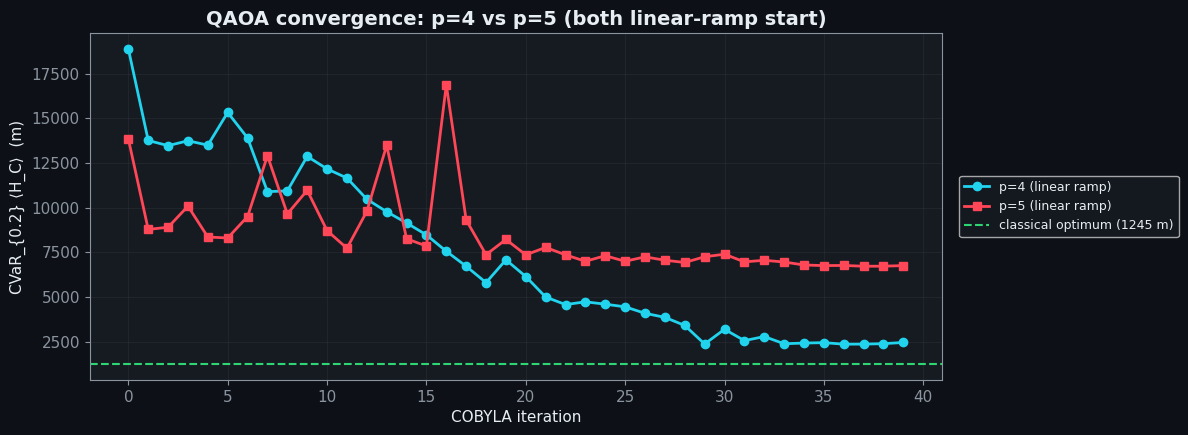

In [16]:
# Convergence: both runs start at iteration 0 (independent optimisations).
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(np.arange(len(history)), history, "o-",
        color=theme.PALETTE["cyan"], lw=2, ms=6,
        label=f"p={P_LAYERS} (linear ramp)")
ax.plot(np.arange(len(history_p5)), history_p5, "s-",
        color=theme.PALETTE["red"], lw=2, ms=6,
        label=f"p={P_LAYERS_2} (linear ramp)")
ax.axhline(opt_len, color=theme.PALETTE["green"], ls="--", lw=1.5,
           label=f"classical optimum ({opt_len:.0f} m)")
ax.set_xlabel("COBYLA iteration")
ax.set_ylabel("CVaR_{0.2} ⟨H_C⟩  (m)")
ax.set_title(f"QAOA convergence: p={P_LAYERS} vs p={P_LAYERS_2} (both linear-ramp start)")
s.place_legend_outside(ax)
plt.show()


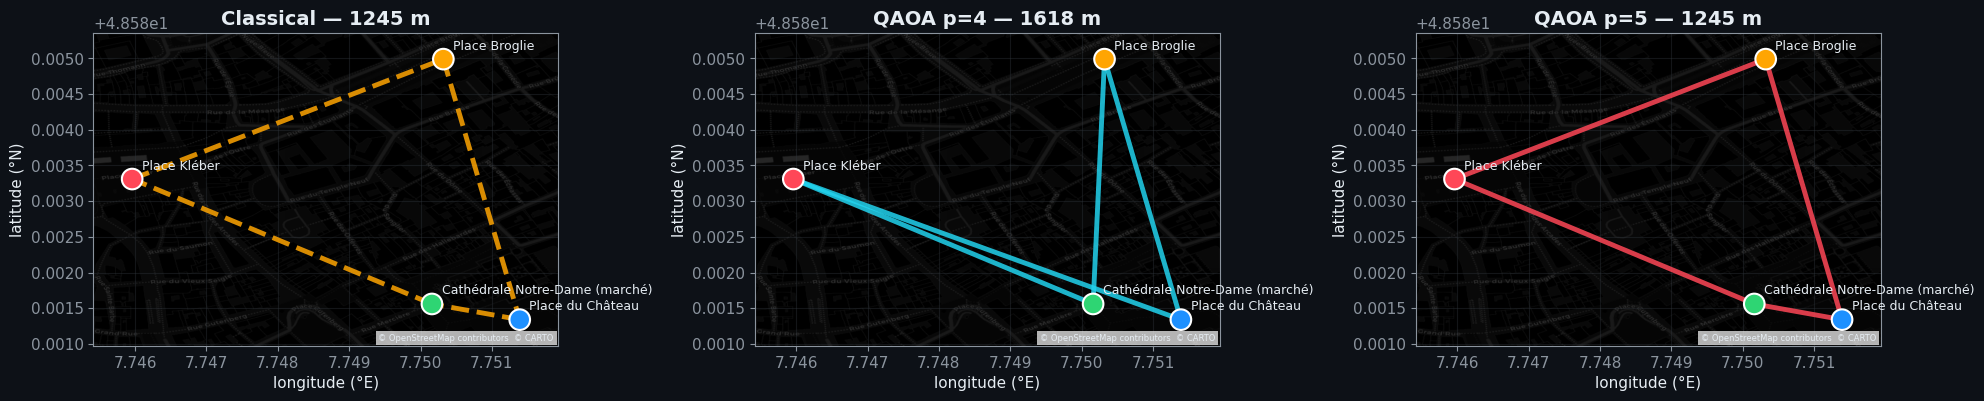

In [17]:
# Three-panel comparison: classical, QAOA p=4, QAOA p=5
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

opt_places = [markets4[i] for i in opt_tour.tolist()]
opt_edges_  = list(zip(opt_places, opt_places[1:] + [opt_places[0]]))
s.plot(places=markets4, edges=opt_edges_, basemap=True, label="name", ax=axes[0],
       edge_color=theme.PALETTE["yellow"], edge_width=3.5, edge_style="--",
       title=f"Classical — {opt_len:.0f} m")

if top_feasible is not None:
    qt = top_feasible[0]
    qp = [markets4[i] for i in qt.tolist()]
    s.plot(places=markets4, edges=list(zip(qp, qp[1:] + [qp[0]])),
           basemap=True, label="name", ax=axes[1],
           edge_color=theme.PALETTE["cyan"], edge_width=3.5,
           title=f"QAOA p={P_LAYERS} — {inst.tour_length(qt):.0f} m")
else:
    axes[1].axis("off"); axes[1].text(0.5, 0.5, f"no feasible at p={P_LAYERS}",
                                        ha="center", va="center")

if top_p5 is not None:
    qt5 = top_p5[0]
    qp5 = [markets4[i] for i in qt5.tolist()]
    s.plot(places=markets4, edges=list(zip(qp5, qp5[1:] + [qp5[0]])),
           basemap=True, label="name", ax=axes[2],
           edge_color=theme.PALETTE["red"], edge_width=3.5,
           title=f"QAOA p={P_LAYERS_2} — {inst.tour_length(qt5):.0f} m")
else:
    axes[2].axis("off"); axes[2].text(0.5, 0.5, f"no feasible at p={P_LAYERS_2}",
                                        ha="center", va="center")

plt.tight_layout()
plt.show()


## Summary

- TSP-4 on the Strasbourg markets fits in **16 qubits** under Lucas-2014.
- Three pipeline calls (`tsp_to_qubo` → `to_ising` → `to_hamiltonian`)
  produce a ready-to-trotterise `mc.Hamiltonian`.
- The QAOA ansatz is a 17-line manual loop; we run it at $p = 4$ and at
  $p = 5$ as **two independent optimisations**, both starting from the
  adiabatic-style linear ramp. Comparing them isolates ansatz depth as
  the only variable that differs between the two runs.
- The CVaR$_{0.2}$ objective focuses the gradient signal on the lowest-α
  fraction of samples — essential when penalty terms make the mean
  energy noisy.
- `mimiq_cache` wraps every cloud round-trip transparently — first run
  hits the cloud, every subsequent run loads `QCSResults` from disk via
  the SDK's native `saveproto`/`loadproto`.
- **Ansatz depth matters**: at $p = 4$ the QAOA approximation ratio is
  typically a few percent off optimum on this instance; running again
  at $p = 5$ from the same kind of warm start usually closes the gap,
  illustrating that more Trotter steps in the discrete adiabatic
  schedule give a finer approximation of the ideal evolution.

For more variants (XY-mixers for permutation constraints, multi-angle
QAOA, RQAOA), see `notes/09-qaoa-and-adiabatic.md` and
`notes/12-mapping-tsp-vrp-to-qaoa.md`.


## Appendix — flush this notebook's cache

This notebook stores **only** entries under the `qaoa-tsp4-` prefix
(`qaoa-tsp4-cobyla`, `qaoa-tsp4-final`, `qaoa-tsp4-p5-cobyla`,
`qaoa-tsp4-p5-final`). The cell below — guarded by `if False:` so it
won't run on a "Restart & Run All" — wipes them and only them. Other
notebooks' caches (`qaoa-server-…`, `fidsweep-…`) are untouched.

Flip the guard to `True` to re-bake every QAOA cell from scratch.


In [ ]:
if False:
    from strasbourg_markets_demo.cache import clear_cache
    n = clear_cache(prefix="qaoa-tsp4-")
    print(f"removed {n} cached entr{'y' if n == 1 else 'ies'} for this notebook")



---

<div style="text-align:center; padding:18px 0 6px 0"></div>

<div style="text-align:center; color:#8b949e; font-size:12px; padding-bottom:8px">© 2026 QPerfect &middot; Released under the MIT License &middot; <a href="https://qperfect.io">qperfect.io</a></div>